# Analysis -- unknown node labels (complex network)

Reads `results_dp_sbm_complex_network.csv` from
`script_no_known_node_label_synthetic_graph.py`.

Three methods, all at the SAME epsilon per (N, sigma) row:

| method | what it is |
|---|---|
| `edge_flip_vem` | VEM-SBM on the flipped adjacency |
| `edge_flip_spectral` | spectral clustering on the **same** flipped release |
| `sbm_dpsgd_all_noised` | fully-variational DP-SGD on the raw graph |

The two edge-flip rows share one release, so their epsilon is the budget for
the pair, not for each -- see `[CHANGE 4]` in the driver.


In [2]:
# -- load results (handles both single-file and sharded output) --------------
import glob
import numpy as np
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_complex_network.csv"   # match OUTPUT_CSV in the driver

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# No sigma=0.1 guard is needed here (unlike the thesis notebook): SIGMAS starts
# at 1.0, so epsilon maxes out around 27 and np.exp(epsilon) never overflows.
# Assert it rather than assume it, in case the grid is widened later.
_bad = df.loc[df["epsilon"] > 700, "sigma"].unique()
assert len(_bad) == 0, f"epsilon > 700 at sigma={_bad}: exp() overflowed in edge_flip"

# -- restrict to the two N values these figures report ----------------------
# N = 1000 is dropped: it sits between the two and every method is saturated
# there, so it adds a row/column without adding a contrast.  The full CSV is
# untouched -- set N_SHOW = sorted(df["N"].unique()) to put it back.
N_SHOW = [100, 10000]
_n_before = len(df)
df = df[df["N"].isin(N_SHOW)].reset_index(drop=True)
print(f"Restricted to N in {N_SHOW}: dropped {_n_before - len(df)} rows, {len(df)} remain.")

print()
print("grid actually present:")
print("  N     :", sorted(df["N"].unique()))
print("  sigma :", sorted(df["sigma"].unique()))
print("  method:", sorted(df["method"].unique()))
print("  reps  :", df.groupby(["N", "sigma", "method"]).size().unique(), "rows per cell")
df.head()

Loaded ./results/results_dp_sbm_complex_network.csv, 900 rows.
Restricted to N in [100, 10000]: dropped 300 rows, 600 remain.

grid actually present:
  N     : [100, 10000]
  sigma : [1.0, 2.0, 5.0, 10.0, 20.0]
  method: ['edge_flip_spectral', 'edge_flip_vem', 'sbm_dpsgd_all_noised']
  reps  : [20] rows per cell


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epochs,epochs_gamma,epochs_beta,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,100,1.0,27.438851,0,edge_flip_vem,NaN,NaN,279.0,NaN,NaN,0.00001,0.2,0.02,0.2,0.203265,0.017200,0.217959,1.000000
1,100,1.0,27.438851,0,edge_flip_spectral,NaN,NaN,NaN,NaN,NaN,0.00001,0.2,0.02,0.2,0.203265,0.017200,0.217959,1.000000
2,100,1.0,27.438851,0,sbm_dpsgd_all_noised,26.32774,5.635918,11.0,6.0,5.0,0.00001,0.2,0.02,0.2,0.209061,0.048848,0.208286,0.807962
3,100,2.0,11.728685,0,edge_flip_vem,NaN,NaN,279.0,NaN,NaN,0.00001,0.2,0.02,0.2,0.203261,0.017192,0.217955,1.000000
4,100,2.0,11.728685,0,edge_flip_spectral,NaN,NaN,NaN,NaN,NaN,0.00001,0.2,0.02,0.2,0.203261,0.017192,0.217955,1.000000


## Coverage and completeness

Long shard arrays fail partway more often than anyone expects. Check what
actually landed before reading any figure.


In [3]:
# -- coverage: which (N, sigma, method) cells are complete? ------------------
counts = (df.groupby(["N", "sigma", "method"]).size()
            .unstack("method").fillna(0).astype(int))
expected = int(counts.values.max()) if counts.size else 0
print(f"expected reps per cell (max seen): {expected}\n")
print(counts.to_string())

missing = counts[(counts < expected).any(axis=1)]
if len(missing):
    print("\nINCOMPLETE cells:")
    print(missing.to_string())
else:
    print("\nAll cells complete.")

# epochs is written for edge_flip_vem and sbm_dpsgd only -- spectral has no
# iterative epoch to count, so its blank column is expected, not a gap.
print("\nnon-null `epochs` by method:")
print(df.groupby("method")["epochs"].apply(lambda s: f"{s.notna().sum()}/{len(s)}").to_string())

expected reps per cell (max seen): 20

method       edge_flip_spectral  edge_flip_vem  sbm_dpsgd_all_noised
N     sigma                                                         
100   1.0                    20             20                    20
      2.0                    20             20                    20
      5.0                    20             20                    20
      10.0                   20             20                    20
      20.0                   20             20                    20
10000 1.0                    20             20                    20
      2.0                    20             20                    20
      5.0                    20             20                    20
      10.0                   20             20                    20
      20.0                   20             20                    20

All cells complete.

non-null `epochs` by method:
method
edge_flip_spectral        0/200
edge_flip_vem           200/200
sbm_dpsgd_a

## NMI

The headline figure. Reference line at NMI = 1.


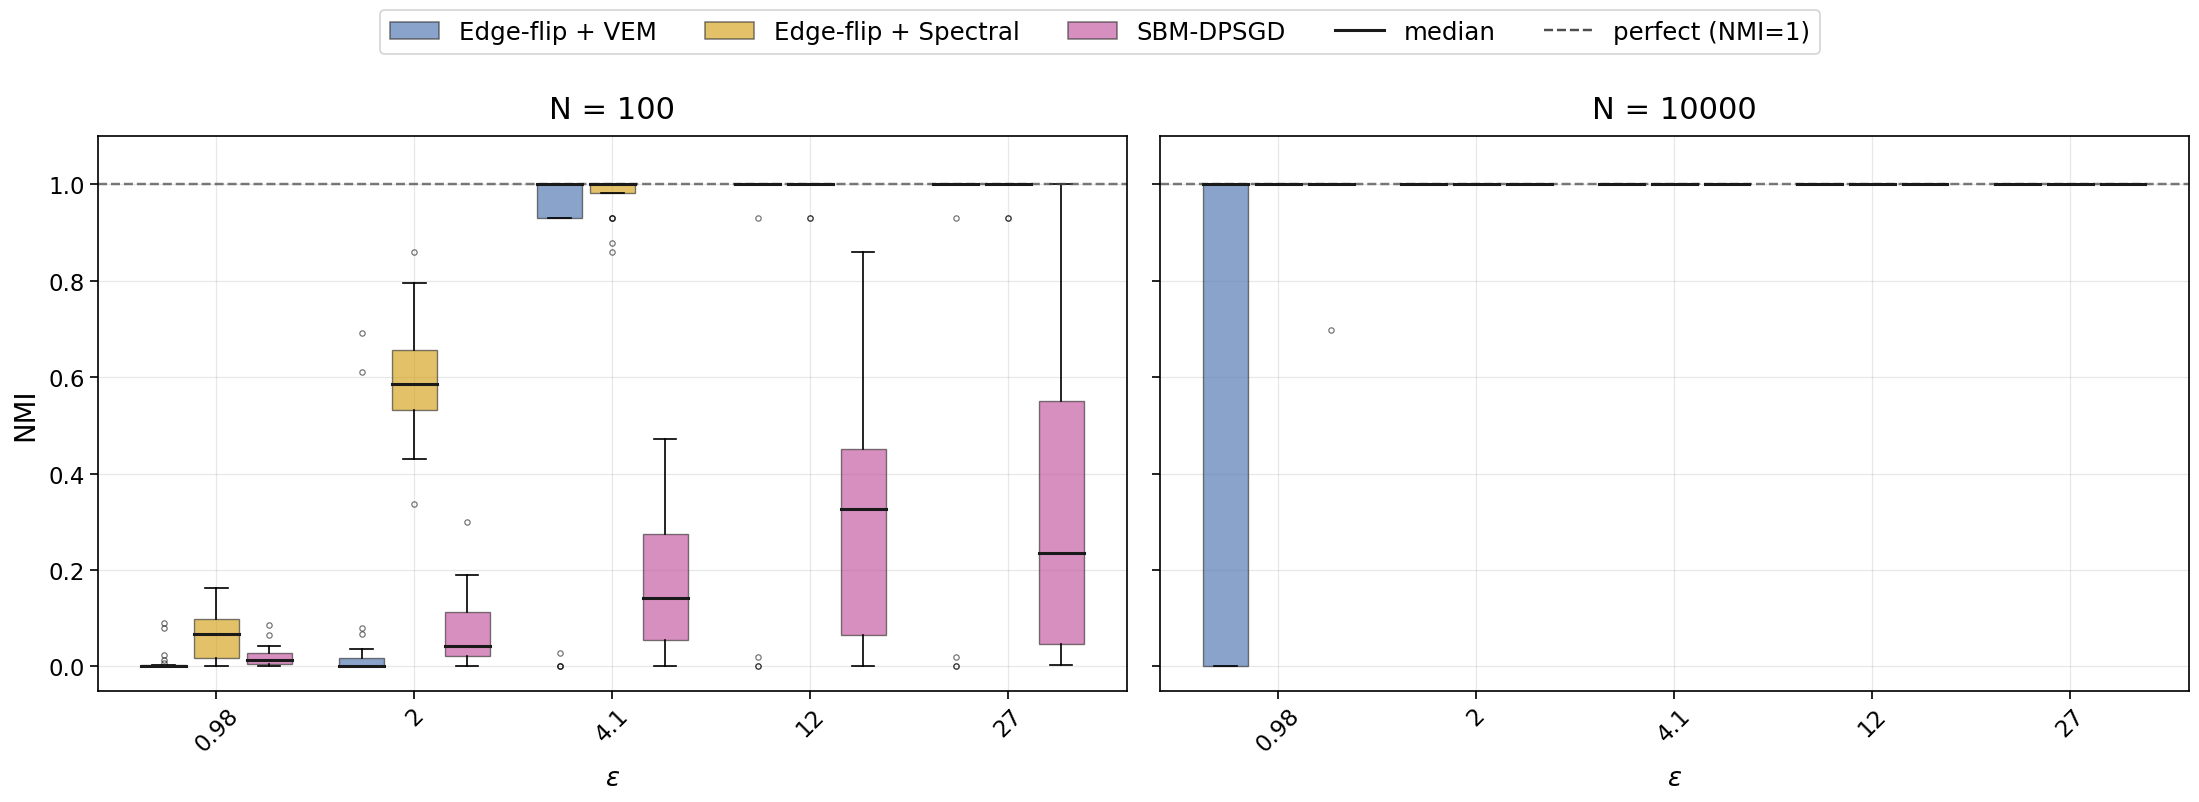

In [4]:
# -- Boxplots of NMI vs epsilon ----------------------------------------------
# Layout: one COLUMN per N, side by side -- a 16:9 frame is wide, not tall,
# and with only two N values the pair reads better across than stacked.
# Both panels share the [0, 1] NMI scale and the y-axis is labelled once on
# the left, so reading across the pair is direct.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

Ns = sorted(df["N"].unique())
methods = order_methods(df["method"].unique())

PANEL_W, PANEL_H = 7.5, 5.4

fig, axes = plt.subplots(
    1, len(Ns),
    figsize=figsize(PANEL_W * len(Ns), PANEL_H),
    sharey=True, squeeze=False,
)

for col, N in enumerate(Ns):
    ax = axes[0, col]
    sub = df[df["N"] == N].dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_title(f"N = {N}", fontsize=20, pad=12)
    if col == 0:
        ax.set_ylabel("NMI", fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="perfect (NMI=1)"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("figures/nmi_complex_network.png", dpi=200, bbox_inches="tight")
plt.show()

### Per-rep spread

`sbm_dpsgd` is bimodal under some hyperparameter settings -- individual reps
land near 1.0 or near 0.0 rather than near their own mean. A boxplot median
hides that; overlaying every rep does not. If a cell's points are split
between the two extremes, its mean describes no run that actually happened.


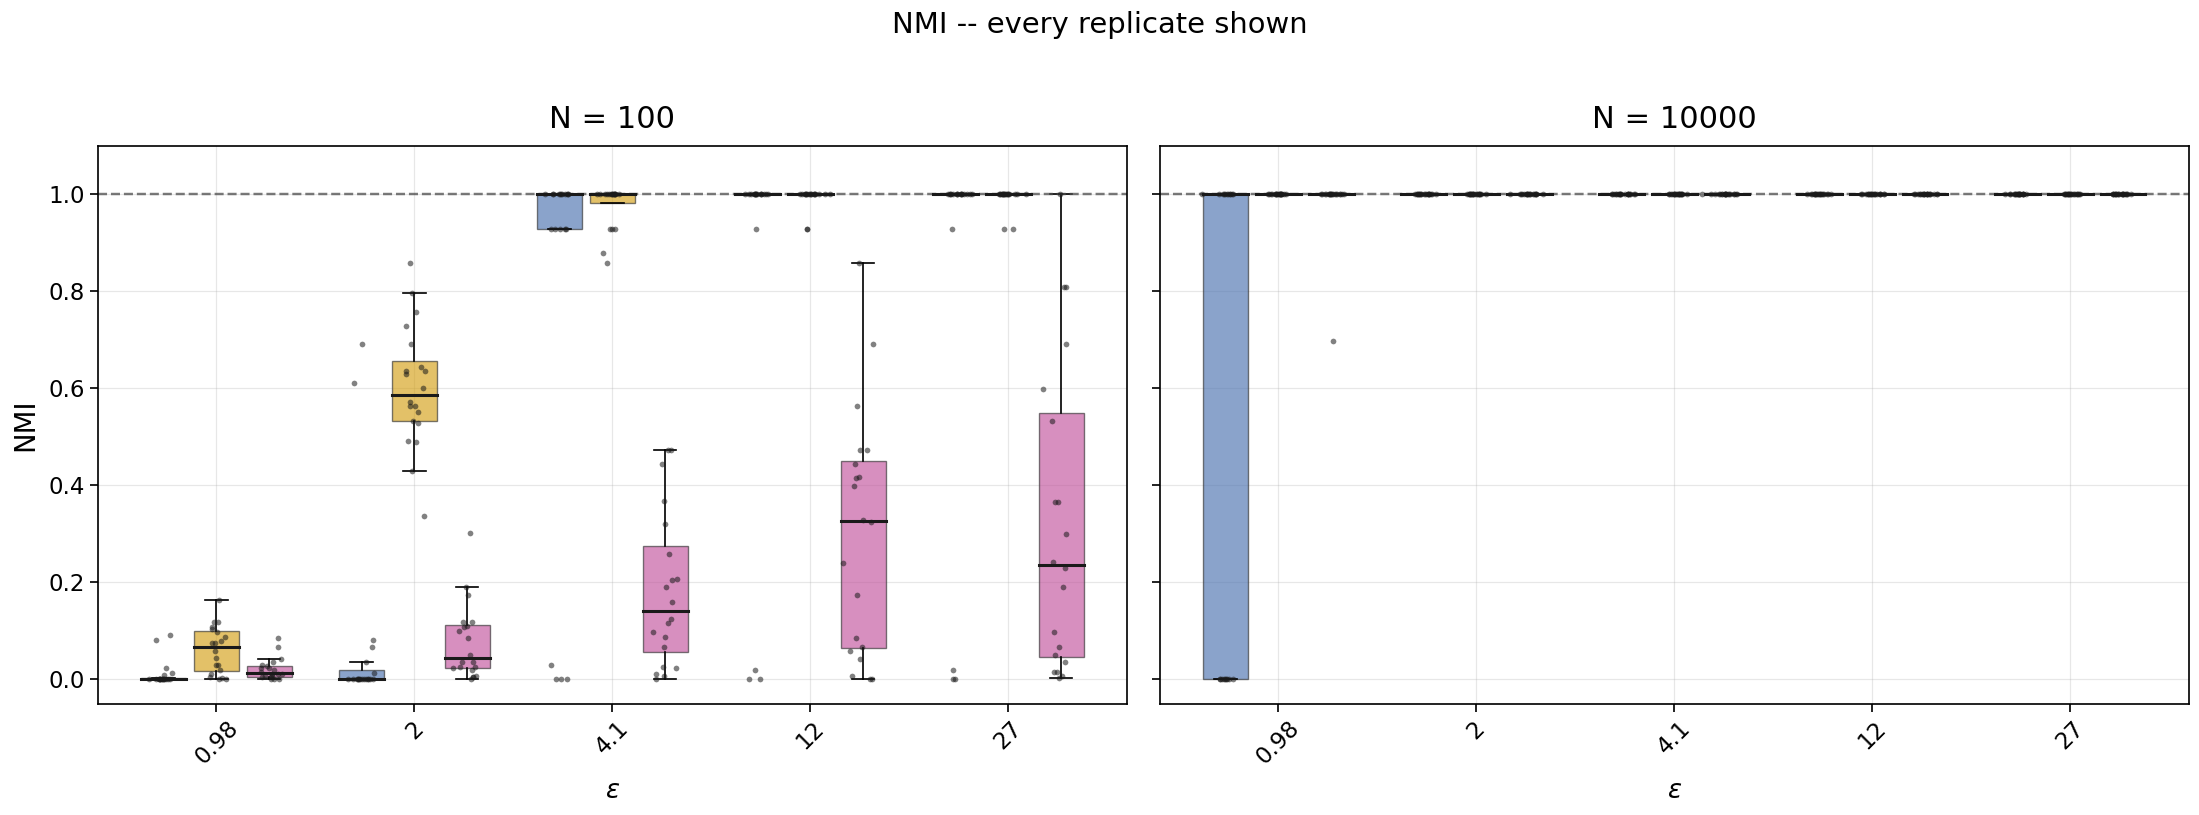

mean NMI  (collapse rate = fraction of reps with NMI < 0.15)

method           edge_flip_spectral           edge_flip_vem    sbm_dpsgd_all_noised
N     sigma                                                                        
100   1.0     0.993  (collapse 0.0)  0.847  (collapse 0.15)   0.321  (collapse 0.4)
      2.0     0.993  (collapse 0.0)  0.847  (collapse 0.15)  0.303  (collapse 0.35)
      5.0     0.976  (collapse 0.0)   0.784  (collapse 0.2)   0.183  (collapse 0.5)
      10.0    0.602  (collapse 0.0)   0.075  (collapse 0.9)  0.077  (collapse 0.85)
      20.0   0.061  (collapse 0.95)   0.011  (collapse 1.0)   0.021  (collapse 1.0)
10000 1.0       1.0  (collapse 0.0)     1.0  (collapse 0.0)     1.0  (collapse 0.0)
      2.0       1.0  (collapse 0.0)     1.0  (collapse 0.0)     1.0  (collapse 0.0)
      5.0       1.0  (collapse 0.0)     1.0  (collapse 0.0)     1.0  (collapse 0.0)
      10.0      1.0  (collapse 0.0)     1.0  (collapse 0.0)     1.0  (collapse 0.0)
      20.0    

In [5]:
# -- every rep, jittered over the box ----------------------------------------
# Same side-by-side layout as the NMI figure above, since this is the same
# quantity with the replicates exposed.
from plot_style import box_positions

apply_style()

fig, axes = plt.subplots(
    1, len(Ns),
    figsize=figsize(PANEL_W * len(Ns), PANEL_H),
    sharey=True, squeeze=False,
)
rng = np.random.default_rng(0)
eps_vals = sorted(df["epsilon"].unique())

for col, N in enumerate(Ns):
    ax = axes[0, col]
    sub = df[df["N"] == N].dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods, showfliers=False)

    pos_map, width = box_positions(methods, eps_vals)
    for ev in eps_vals:
        for m in methods:
            v = sub.loc[(sub["epsilon"] == ev) & (sub["method"] == m), "nmi"].values
            if len(v) == 0:
                continue
            x = pos_map[(ev, m)] + rng.normal(0, width * 0.12, len(v))
            ax.scatter(x, v, s=14, color="#1A1A1A", alpha=0.55, zorder=4,
                       linewidths=0)

    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_title(f"N = {N}", fontsize=20, pad=12)
    if col == 0:
        ax.set_ylabel("NMI", fontsize=18)

fig.suptitle("NMI -- every replicate shown", fontsize=19, y=1.02)
plt.tight_layout()
plt.show()

# bimodality flag: see the markdown above for how to read this.
def collapse_rate(s):
    s = s.dropna()
    return np.nan if len(s) == 0 else (s < 0.15).mean()

mean_tbl = df.pivot_table(index=["N", "sigma"], columns="method",
                          values="nmi", aggfunc="mean").round(3)
coll_tbl = df.pivot_table(index=["N", "sigma"], columns="method",
                          values="nmi", aggfunc=collapse_rate).round(2)

combined = mean_tbl.astype(str) + "  (collapse " + coll_tbl.astype(str) + ")"
print("mean NMI  (collapse rate = fraction of reps with NMI < 0.15)\n")
print(combined.to_string())

flagged = [(idx, m) for m in coll_tbl.columns for idx, v in coll_tbl[m].items()
           if v is not None and v == v and 0.15 < v < 0.85]
if flagged:
    print("\nBIMODAL cells (collapse rate strictly between 0.15 and 0.85) --")
    print("their means are not descriptive; use the per-rep scatter above:")
    for (N, sg), m in flagged:
        print(f"  N={N:<6} sigma={sg:<5} {m:<22} "
              f"mean={mean_tbl.loc[(N, sg), m]:.3f}  collapse={coll_tbl.loc[(N, sg), m]:.2f}")
else:
    print("\nNo bimodal cells detected.")

## Estimated beta


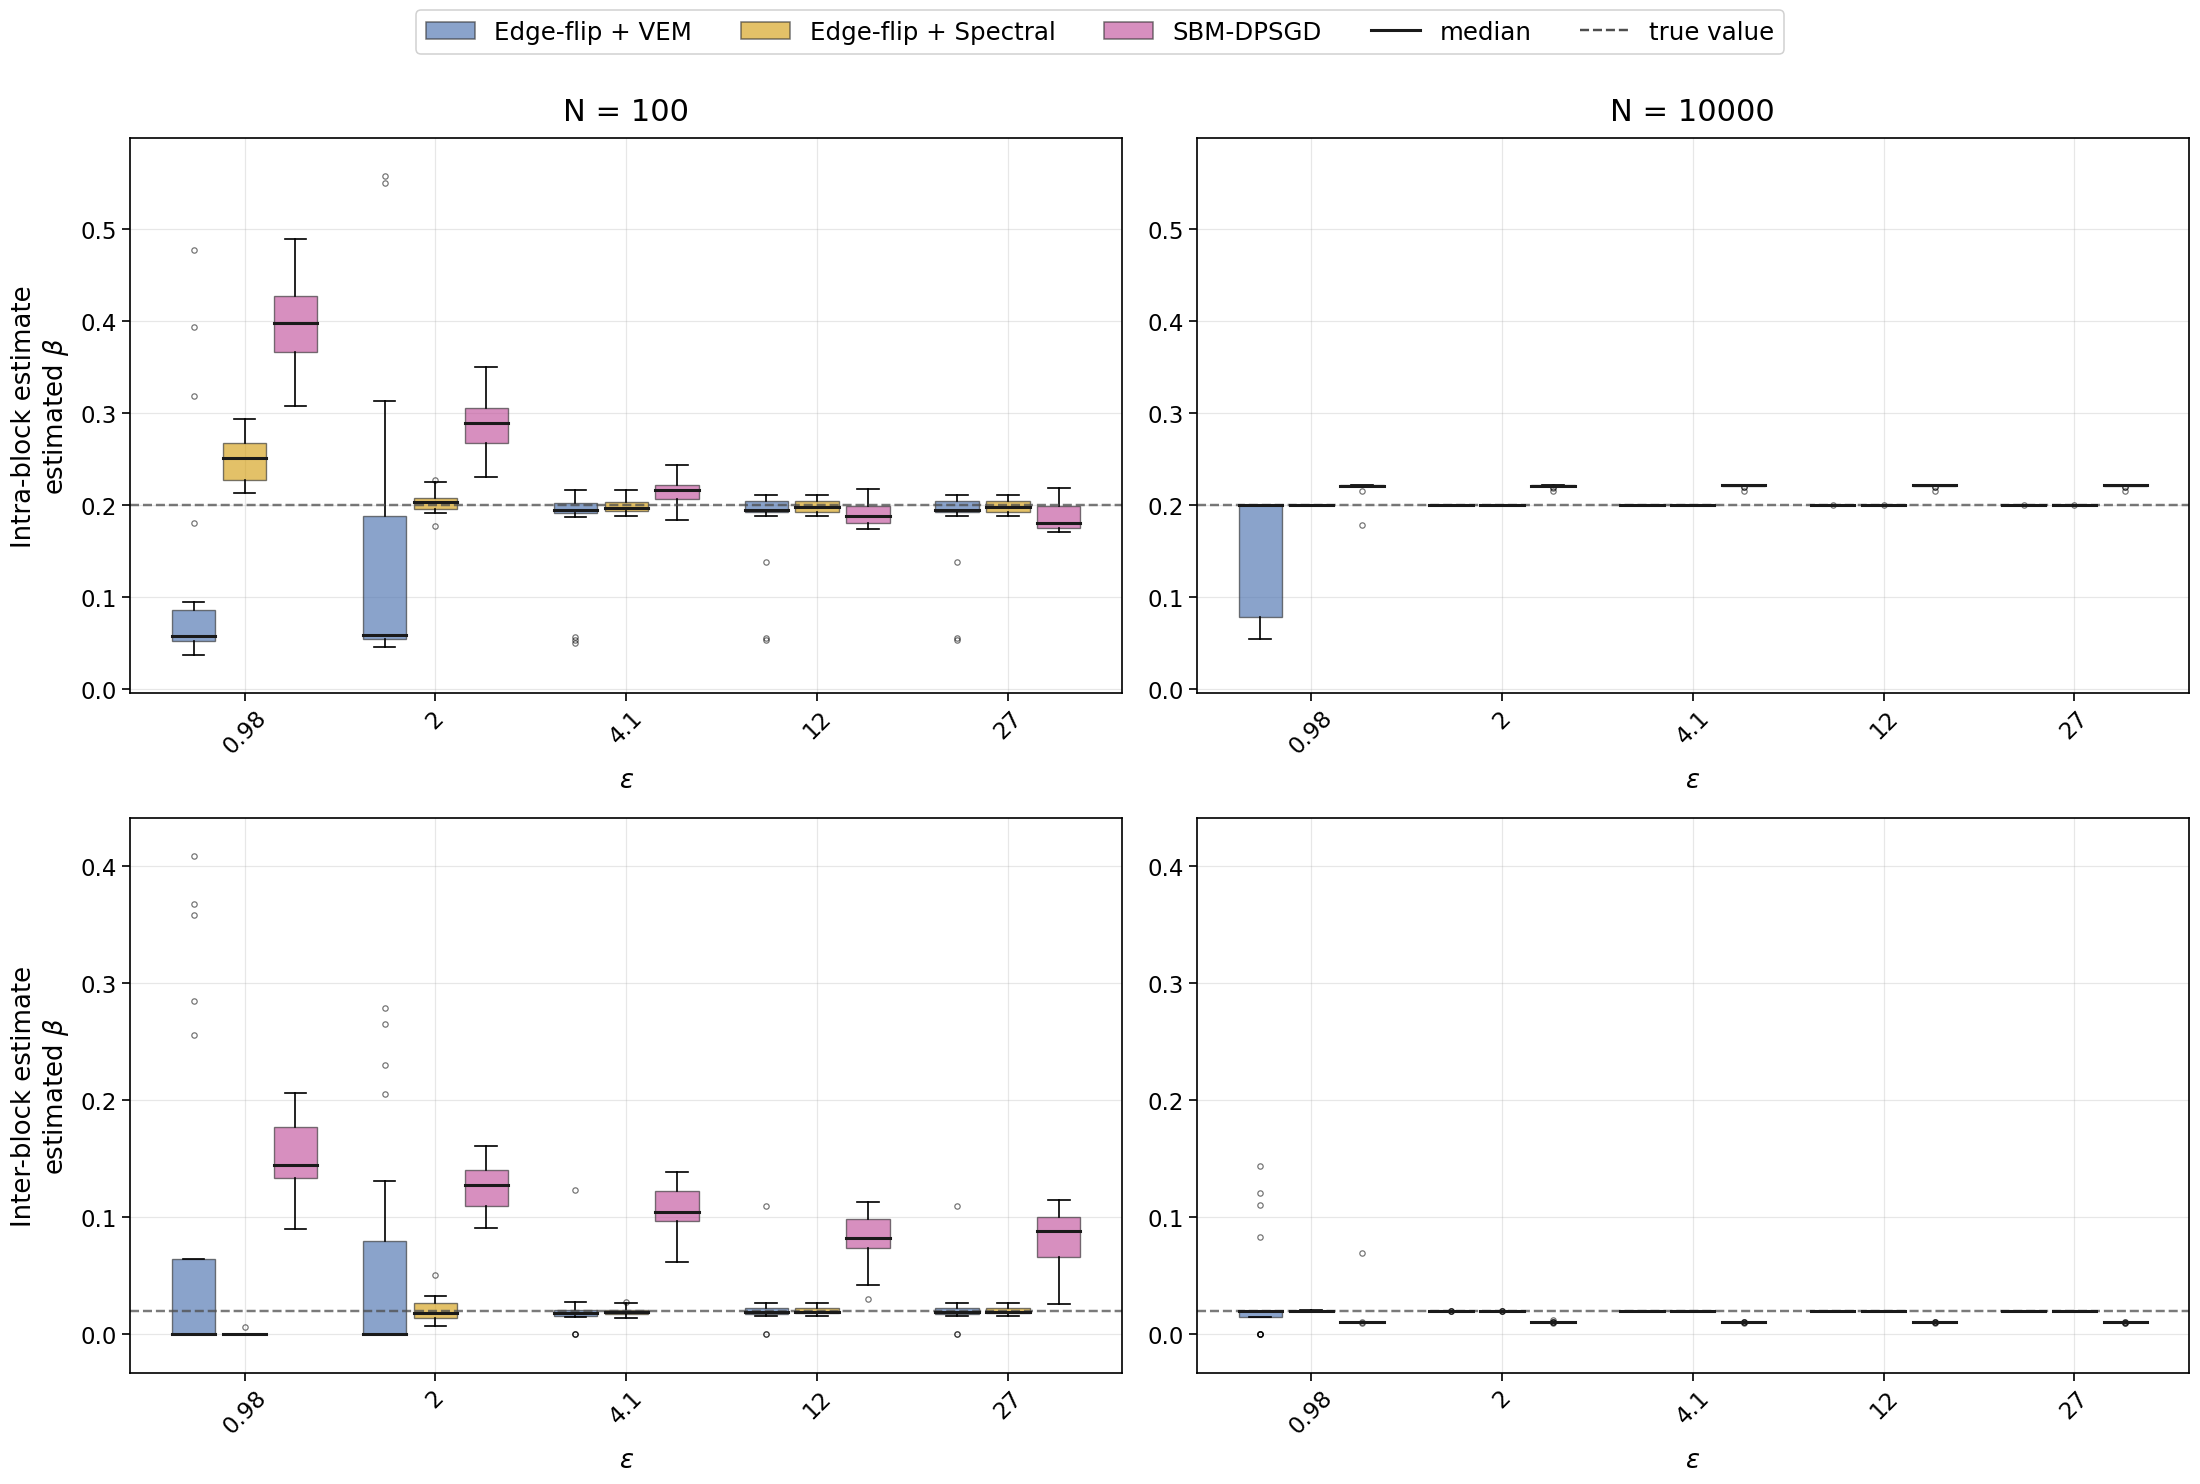

In [6]:
# -- Boxplots of estimated beta vs epsilon -----------------------------------
# Layout: one COLUMN per N (matching the NMI figure), one ROW per block type.
# Each ROW shares a y-limit, so reading ACROSS a row compares the same
# quantity between the two N.  Intra and inter are NOT put on a common scale
# -- the true values differ by 10x (0.2 vs 0.02) and a shared axis would
# flatten the inter row.
apply_style()

PANEL_W_B, PANEL_H_B = 7.5, 5.0

df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

ROWS = [
    ("intra_est",   "beta_true_00", "Intra-block estimate"),
    ("beta_est_01", "beta_true_01", "Inter-block estimate"),
]
# per-ROW y-limits, shared across the N columns
ylims = []
for est_col, true_col, _ in ROWS:
    lo = min(df[est_col].min(), df[true_col].min())
    hi = max(df[est_col].max(), df[true_col].max())
    ylims.append(pad(lo, hi))

fig, axes = plt.subplots(
    len(ROWS), len(Ns),
    figsize=figsize(PANEL_W_B * len(Ns), PANEL_H_B * len(ROWS)),
    squeeze=False,
)

for row, (est_col, true_col, row_title) in enumerate(ROWS):
    for col, N in enumerate(Ns):
        ax = axes[row, col]
        sub = df[df["N"] == N]
        grouped_boxplot(ax, sub, est_col, methods=methods)
        reference_line(ax, sub[true_col].iloc[0])
        ax.set_ylim(ylims[row])
        ax.set_xlabel(r"$\epsilon$")
        if row == 0:
            ax.set_title(f"N = {N}", fontsize=20, pad=12)
        if col == 0:
            ax.set_ylabel(f"{row_title}\n" r"estimated $\beta$", fontsize=17)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="true value"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("figures/beta_complex_network.png", dpi=200, bbox_inches="tight")
plt.show()

## Compute cost (epochs)

**An epoch is not wall-clock comparable across methods.** A VEM epoch is a
dense O(N^2) matmul pass; an SBM-DPSGD epoch is a sampled per-example
autodiff pass. `edge_flip_spectral` is absent by construction -- spectral
clustering has no iterative epoch to count.


methods with an epoch count: ['edge_flip_vem', 'sbm_dpsgd_all_noised']


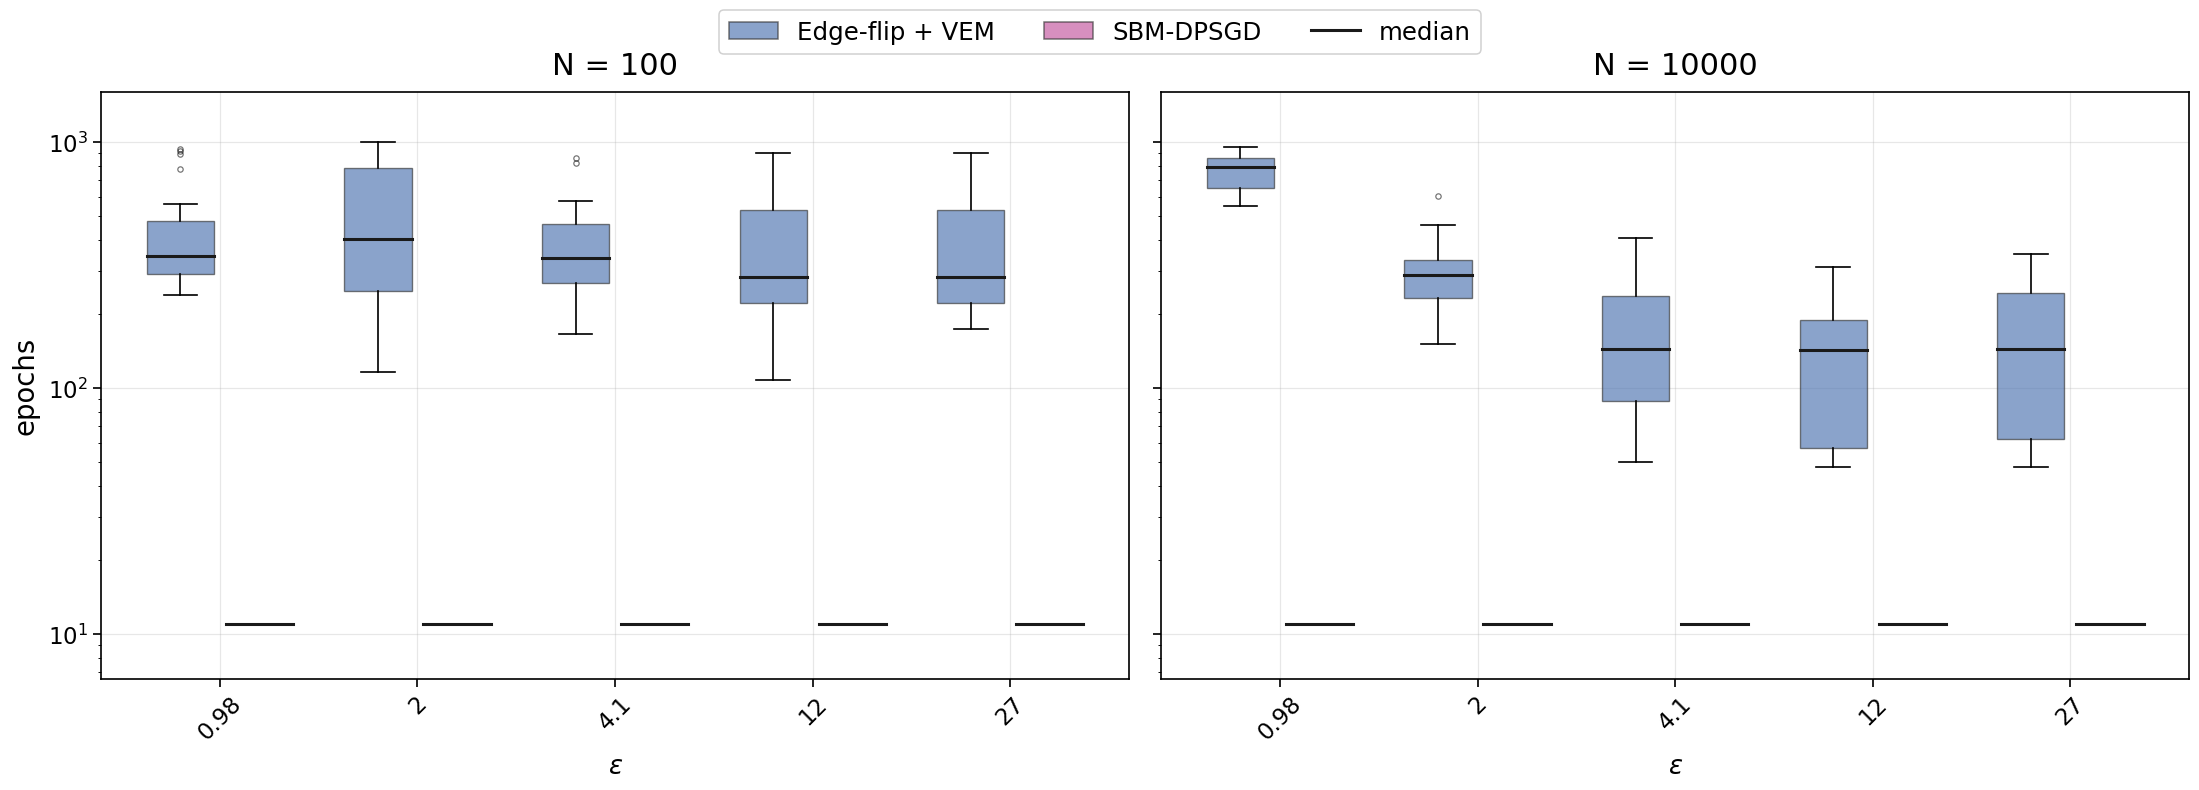

In [7]:
# -- Boxplots of # epochs (compute cost) vs epsilon --------------------------
# Log scale: the methods differ by ~1-2 orders of magnitude, so a linear axis
# squashes the cheaper one flat near zero.
apply_style()

df_ep = df.dropna(subset=["epochs"])
methods_ep = order_methods(df_ep["method"].unique())
print("methods with an epoch count:", methods_ep)

fig, axes = plt.subplots(1, len(Ns),
                         figsize=figsize(PANEL_W * len(Ns), PANEL_H),
                         sharey=True, squeeze=False)

ep_lo = max(df_ep["epochs"].min() * 0.6, 1e-3)
ep_hi = df_ep["epochs"].max() * 1.6

for col, N in enumerate(Ns):
    ax = axes[0, col]
    sub = df_ep[df_ep["N"] == N]
    grouped_boxplot(ax, sub, "epochs", methods=methods_ep)
    ax.set_yscale("log")
    ax.set_ylim(ep_lo, ep_hi)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_title(f"N = {N}", fontsize=20, pad=12)
    if col == 0:
        ax.set_ylabel("epochs", fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods_ep]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("figures/epochs_complex_network.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary table


In [8]:
# -- numbers behind the figures ----------------------------------------------
summary = (df.groupby(["N", "sigma", "epsilon", "method"])
             .agg(nmi_mean=("nmi", "mean"),
                  nmi_std=("nmi", "std"),
                  nmi_min=("nmi", "min"),
                  nmi_max=("nmi", "max"),
                  intra=("beta_est_00", "mean"),
                  inter=("beta_est_01", "mean"),
                  n=("nmi", "size"))
             .round(4))
print(summary.to_string())

print("\n\nmean NMI, methods side by side:")
print(df.pivot_table(index=["N", "sigma"], columns="method",
                     values="nmi", aggfunc="mean").round(3).to_string())

                                            nmi_mean  nmi_std  nmi_min  nmi_max   intra   inter   n
N     sigma epsilon   method                                                                       
100   1.0   27.438851 edge_flip_spectral      0.9929   0.0218   0.9291   1.0000  0.1972  0.0201  20
                      edge_flip_vem           0.8474   0.3628   0.0000   1.0000  0.1777  0.0224  20
                      sbm_dpsgd_all_noised    0.3209   0.3153   0.0026   1.0000  0.1898  0.0811  20
      2.0   11.728685 edge_flip_spectral      0.9929   0.0218   0.9291   1.0000  0.1972  0.0201  20
                      edge_flip_vem           0.8474   0.3628   0.0000   1.0000  0.1779  0.0224  20
                      sbm_dpsgd_all_noised    0.3031   0.2474   0.0012   0.8586  0.1951  0.0837  20
      5.0   4.148451  edge_flip_spectral      0.9762   0.0451   0.8586   1.0000  0.1977  0.0195  20
                      edge_flip_vem           0.7837   0.3995   0.0000   1.0000  0.1703  0.0218  20


## Slide figure


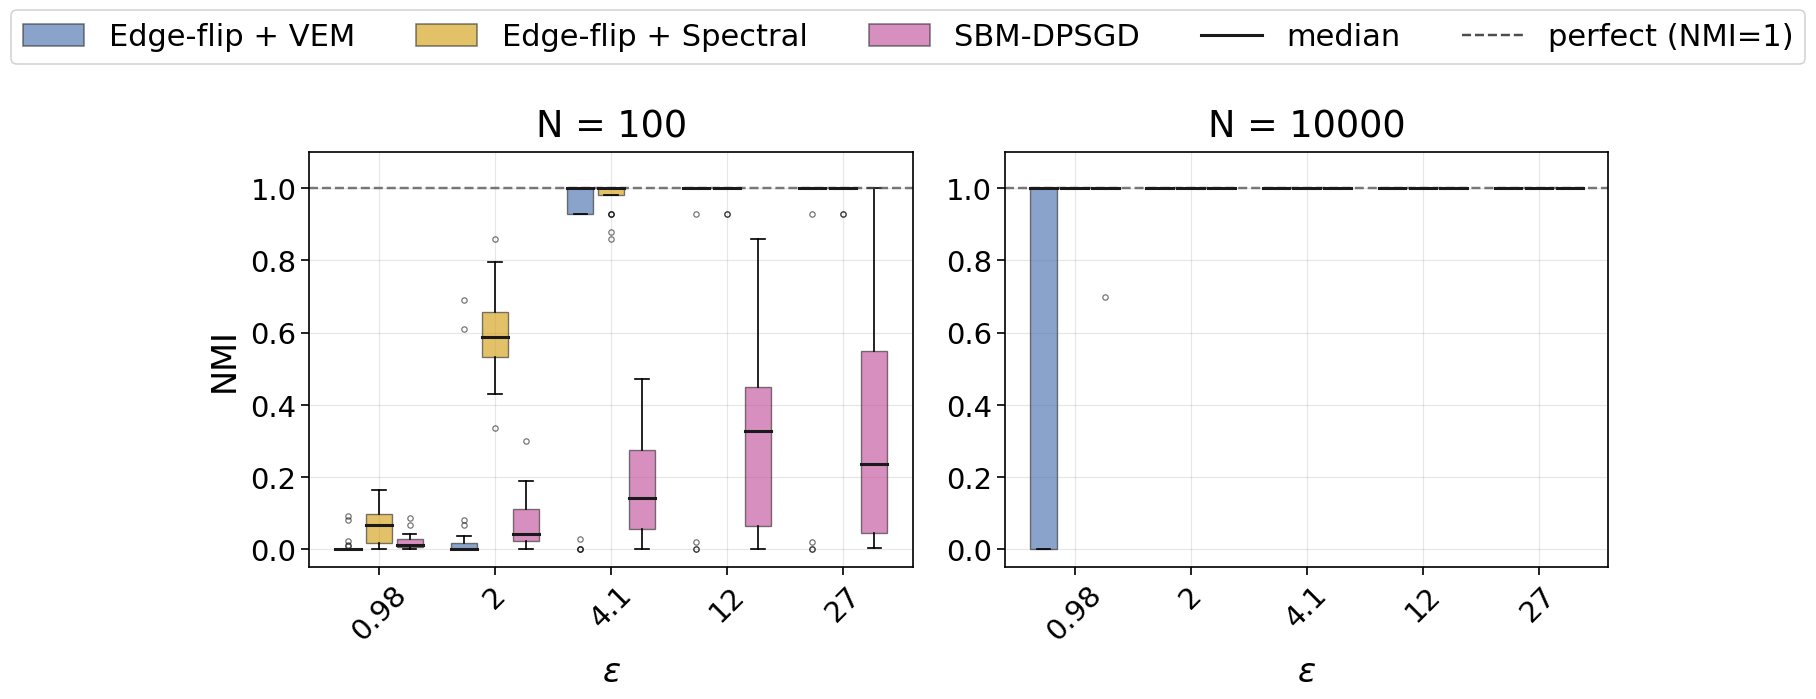

In [9]:
# -- SLIDE version of the NMI figure -----------------------------------------
# Same data, re-laid-out for a talk: a 16:9 frame is wide, not tall, so the N
# values go side by side and type is set in literal slide points.
SLIDE_NS = Ns                                 # both N values
SLIDE_W, SLIDE_H = 13.33, 6.6
SLIDE_RC = {
    "font.size": 20, "axes.labelsize": 22, "xtick.labelsize": 19,
    "ytick.labelsize": 19, "legend.fontsize": 20,
}

dfs = df[df["N"].isin(SLIDE_NS)]
Ns_slide = [n for n in SLIDE_NS if n in set(dfs["N"])]
methods_slide = order_methods(dfs["method"].unique())

apply_style()
with plt.rc_context(SLIDE_RC):
    fig, axes = plt.subplots(1, len(Ns_slide), figsize=(SLIDE_W, SLIDE_H),
                             squeeze=False)
    for col, N in enumerate(Ns_slide):
        ax = axes[0, col]
        sub = dfs[dfs["N"] == N].dropna(subset=["nmi"])
        grouped_boxplot(ax, sub, "nmi", methods=methods_slide)
        reference_line(ax, 1.0)
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlabel(r"$\epsilon$")
        ax.set_title(f"N = {N}", fontsize=24, pad=10)
        if col == 0:
            ax.set_ylabel("NMI", fontsize=22)

    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA,
                     edgecolor="#333333", label=method_label(m))
               for m in methods_slide]
    handles += [
        Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
        Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
               label="perfect (NMI=1)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=20, frameon=True, bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout(rect=[0, 0, 1, 0.89])
    fig.savefig("figures/slide_nmi_complex_network.png", dpi=200)
    plt.show()

## Combined figure: NMI and beta in one panel

The three quantities stacked on a shared epsilon axis, one column per N.
Reading DOWN a column shows what a single privacy budget buys on all three
at once -- which is the comparison that matters, since a method can recover
the labels (NMI) while still getting the edge probabilities (beta) wrong,
and vice versa.

Each ROW shares its own y-limits across the two N columns, so reading ACROSS
compares like with like. The rows are NOT on a common scale: NMI is on
[0, 1], intra-beta sits near 0.2 and inter-beta near 0.02, so one shared
axis would flatten the bottom two rows into lines.

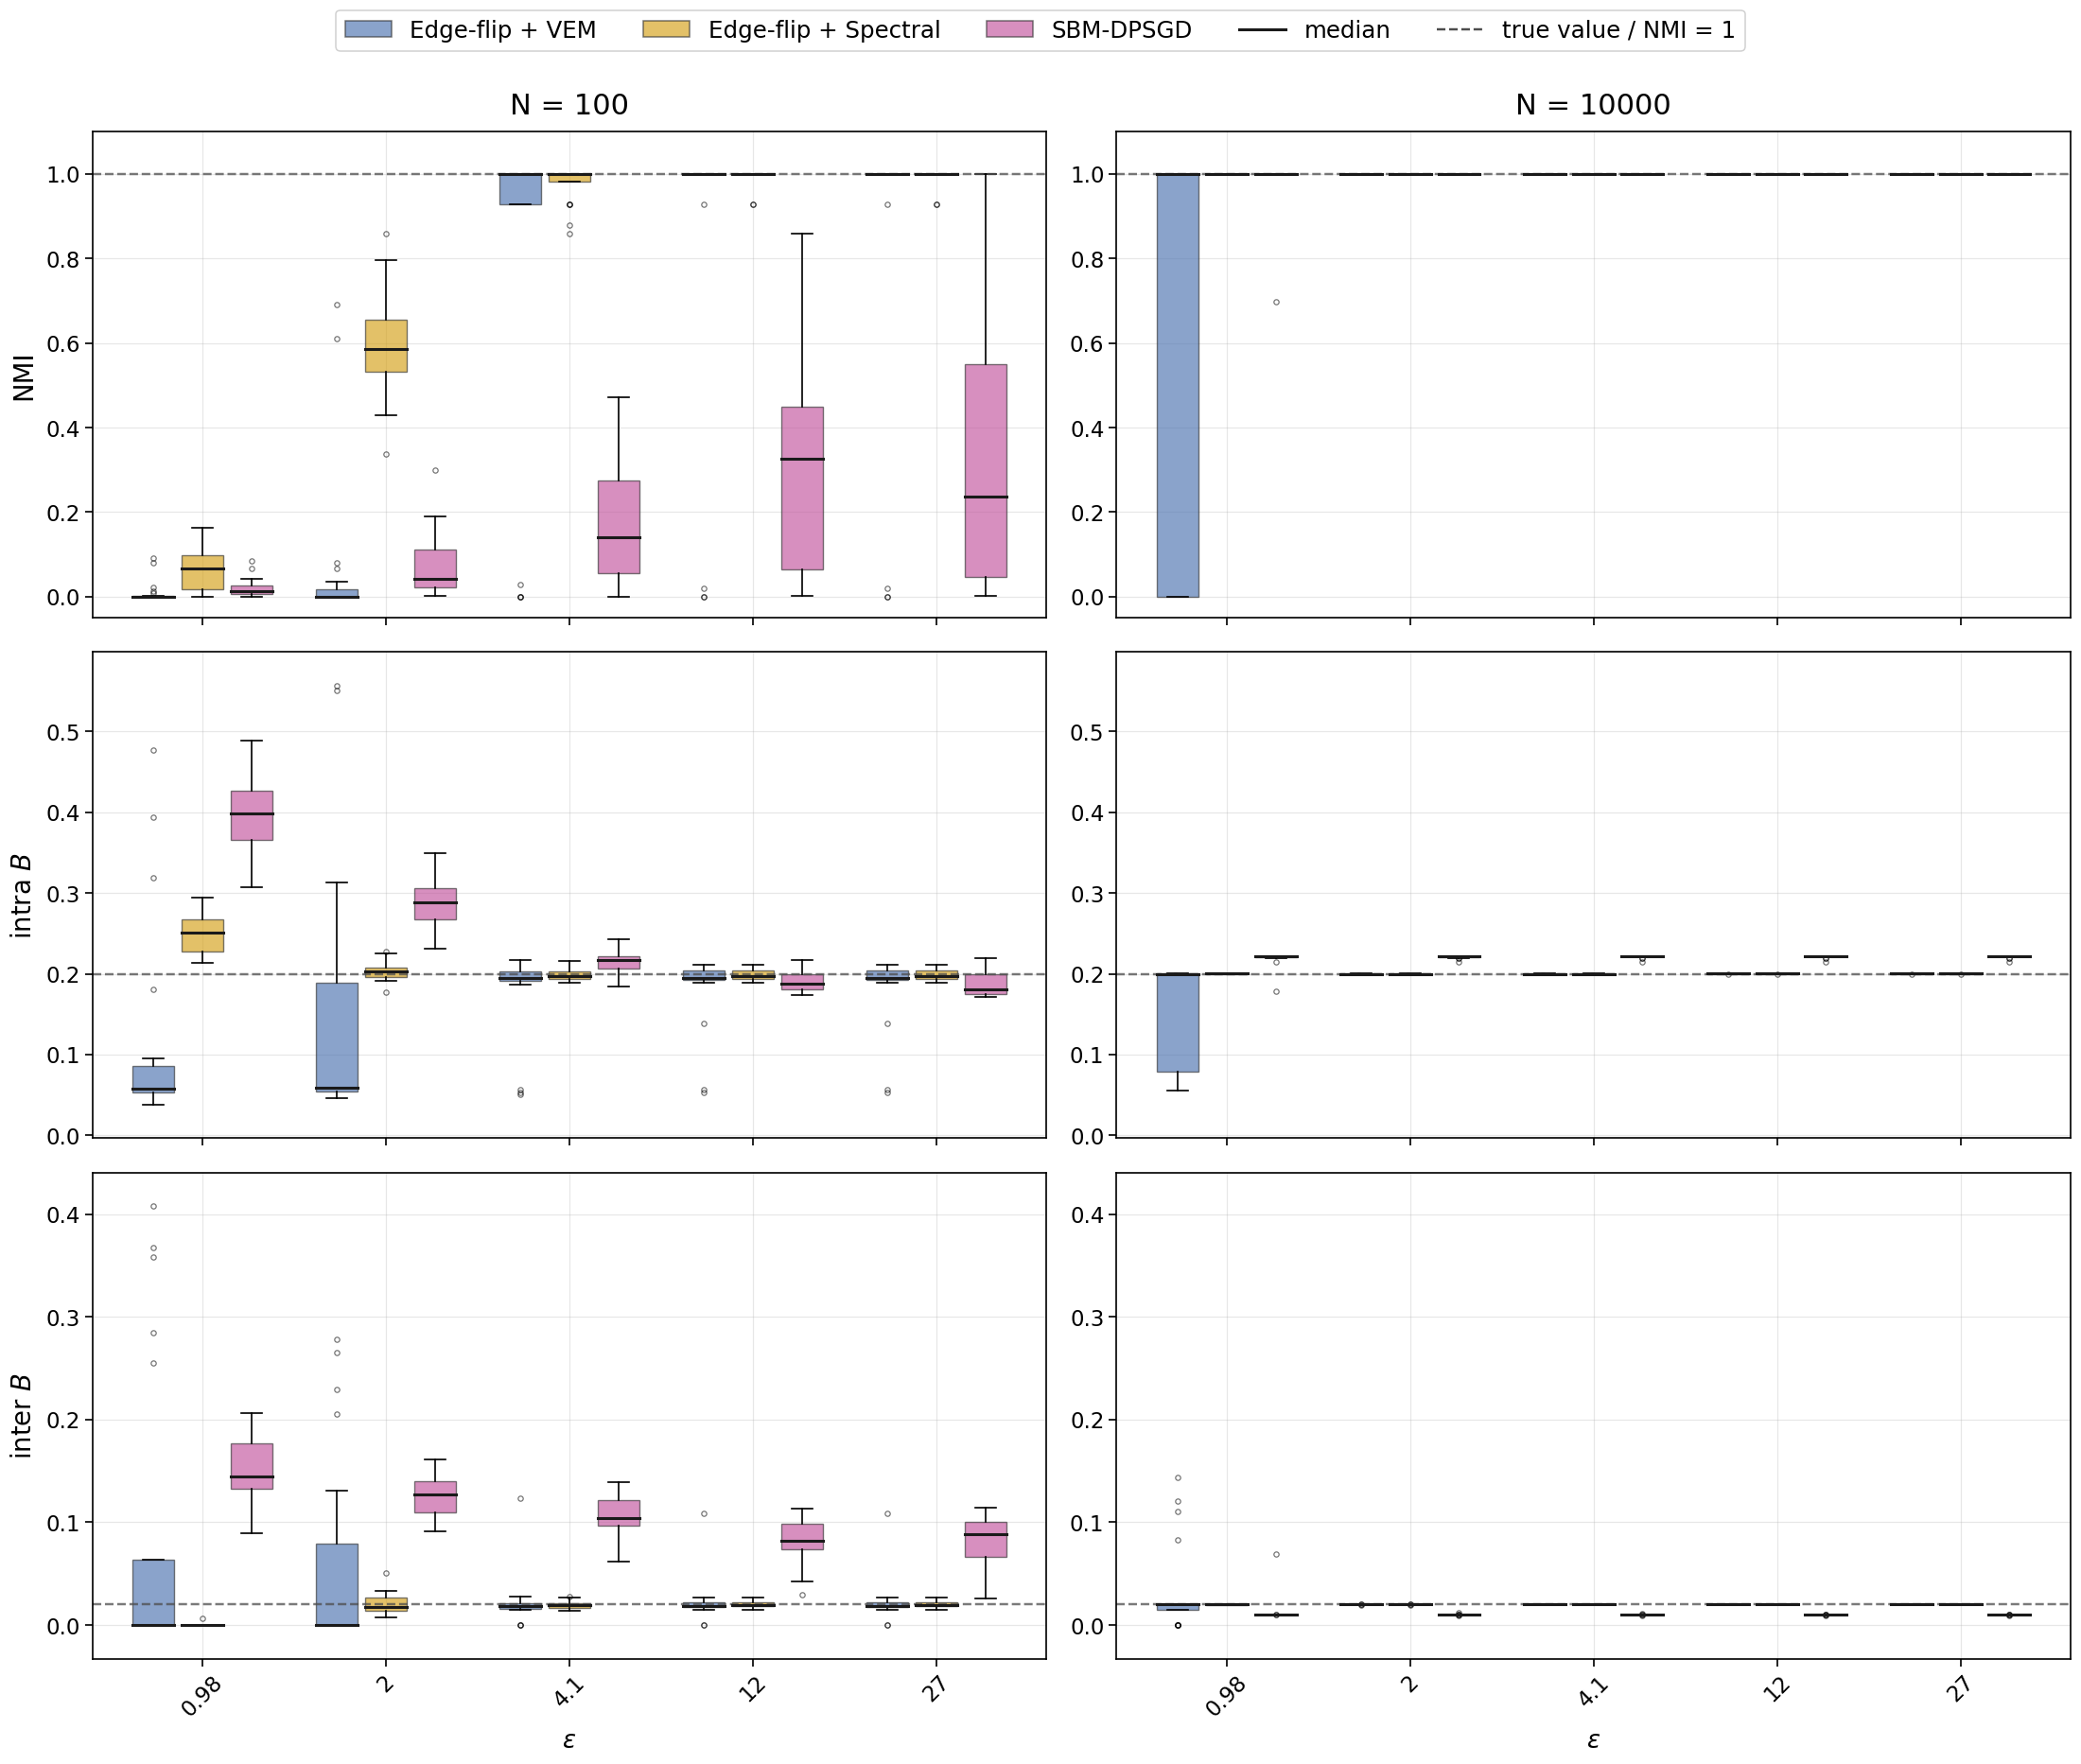

In [10]:
# -- NMI + beta stacked into one figure --------------------------------------
# Rows: NMI, intra-block beta, inter-block beta.  Columns: N.
# x (epsilon) is shared down each column, so tick labels appear once at the
# bottom and the three rows line up against the same budget.
apply_style()

PANEL_W_C, PANEL_H_C = 7.5, 4.2

df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)

def _pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

# (value column, true-value column or None, row label, y-limits)
ROWS = []
ROWS.append(("nmi", None, "NMI", (-0.05, 1.1)))
for est_col, true_col, label in [("intra_est", "beta_true_00", r"intra $B$"),
                                 ("beta_est_01", "beta_true_01", r"inter $B$")]:
    lo = min(df[est_col].min(), df[true_col].min())
    hi = max(df[est_col].max(), df[true_col].max())
    ROWS.append((est_col, true_col, label, _pad(lo, hi)))

fig, axes = plt.subplots(
    len(ROWS), len(Ns),
    figsize=figsize(PANEL_W_C * len(Ns), PANEL_H_C * len(ROWS)),
    sharex="col", squeeze=False,
)

for row, (val_col, true_col, row_label, ylim) in enumerate(ROWS):
    for col, N in enumerate(Ns):
        ax = axes[row, col]
        sub = df[df["N"] == N].dropna(subset=[val_col])
        grouped_boxplot(ax, sub, val_col, methods=methods)
        # reference: perfect NMI on the top row, the true beta below
        reference_line(ax, 1.0 if true_col is None else sub[true_col].iloc[0])
        ax.set_ylim(ylim)
        if row == 0:
            ax.set_title(f"N = {N}", fontsize=20, pad=12)
        if row == len(ROWS) - 1:
            ax.set_xlabel(r"$\epsilon$")
        if col == 0:
            ax.set_ylabel(row_label, fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="true value / NMI = 1"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("figures/nmi_beta_complex_network.png", dpi=200, bbox_inches="tight")
plt.show()